In [1]:
import geopandas
import pandas as pd
import numpy as np
from shapely.geometry import box

import matplotlib.pyplot as plt

In [2]:
%cd /g/data/w42/dr6273/work/wind_drought/

/g/data/w42/dr6273/work/wind_drought


In [3]:
FILEPATH = "/g/data/ng72/dr6273/work/projects/wind_drought/data/"

### NEM

In [4]:
# Load capacity data
_gen = pd.read_csv("REZ_potential.csv", index_col=0)
# Tidy column names
_gen.columns = [i.replace("90", "9-") for i in _gen.columns]
_gen.columns = [i.replace(" ", "_") for i in _gen.columns]
# Select wind and step change
_gen = _gen[[
    "Existing_wind", "Step_change_wind_2029-30", "Step_change_wind_2039-40", "Step_change_wind_2049-50"
]]
# Sum scenarios with existing capacity
gen = _gen.copy()
for col in _gen.columns:
    if col[:3] == "Exi":
        pass
    else:
        gen_type = col.split("_")[-2]
        gen[col] = _gen[col] + _gen["Existing_" + gen_type]

In [5]:
gen.head()

,Existing_wind,Step_change_wind_2029-30,Step_change_wind_2039-40,Step_change_wind_2049-50
REZ,,,,
N1,0,0,0,0
N2,442,3442,7842,7842
N3,673,6123,6123,8473
N4,198,298,298,348
N5,0,600,600,1000


In [6]:
# NEM shapefile
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp"
).drop(["code_2023", "code_SC205"], axis=1)

In [7]:
rez_gpd["REZ_id"] = [i.split(" ")[0] for i in rez_gpd["Name"]]

In [8]:
rez_gpd["Existing_wind"] = 0
rez_gpd["SC2030"] = 0

In [9]:
for i in range(len(rez_gpd.index)):
    r = rez_gpd.iloc[i]["REZ_id"]
    rez_gpd.loc[rez_gpd["REZ_id"] == r, "Existing_wind"] = gen.loc[r, "Existing_wind"]
    rez_gpd.loc[rez_gpd["REZ_id"] == r, "SC2030"] = gen.loc[r, "Step_change_wind_2029-30"]
    rez_gpd.loc[rez_gpd["REZ_id"] == r, "SC2040"] = gen.loc[r, "Step_change_wind_2039-40"]
    rez_gpd.loc[rez_gpd["REZ_id"] == r, "SC2050"] = gen.loc[r, "Step_change_wind_2049-50"]

In [10]:
# rez_gpd = rez_gpd.set_index("REZ_id")

In [11]:
rez_gpd.head()

,Name,Type,longitude,latitude,geometry,REZ_id,Existing_wind,SC2030,SC2040,SC2050
0,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",Q1,332,1082,1132.0,1432.0
1,Q2 North Qld Clean Energy Hub,REZ,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",Q2,43,1993,2693.0,4743.0
2,Q3 Northern Qld,REZ,146.333143,-19.197589,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1...",Q3,0,0,0.0,0.0
3,Q4 Isaac,REZ,148.339869,-21.393793,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -...",Q4,439,1439,2339.0,4239.0
4,Q5 Barcaldine,REZ,145.595326,-22.855731,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2...",Q5,0,100,100.0,100.0


In [12]:
# capacity = rez_gpd[rez_gpd.columns[-4:]].sum()

In [13]:
# capacity

<Axes: >

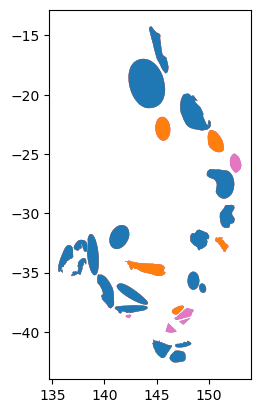

In [14]:
# 5 REZs that don't have wind now will have wind by 2030. By 2040 and 2050 a further 3 will have wind
fig, ax = plt.subplots(1,1)
rez_gpd.loc[rez_gpd["SC2050"] > 0].plot(ax=ax, color="tab:purple")
rez_gpd.loc[rez_gpd["SC2040"] > 0].plot(ax=ax, color="tab:pink")
rez_gpd.loc[rez_gpd["SC2030"] > 0].plot(ax=ax, color="tab:orange")
rez_gpd.loc[rez_gpd["Existing_wind"] > 0].plot(ax=ax)

We want a full NEM grid, using wind REZs for each scenario year, plus another one that excludes QLD and TAS.

In [15]:
SE_grid_REZs = np.array(
    [
        'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10', 'N11', 'N12',
        'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8',
        'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10'
    ]
    , dtype="<U3"
)

Use 2030 grid as it only excludes a few REZs from 2040 and 2050

In [56]:
nem_2030 = rez_gpd.loc[rez_gpd["SC2030"] > 0].dissolve()
se_2030 = rez_gpd.loc[(rez_gpd["REZ_id"].isin(SE_grid_REZs)) & (rez_gpd["SC2030"] > 0)].dissolve()

In [85]:
nem_grids = geopandas.GeoDataFrame(
    pd.concat([nem_2030, se_2030], ignore_index=True),
    crs=rez_gpd.crs  # make sure CRS matches original
)

In [86]:
nem_grids["grid"] = ["NEM_2030", "SE_2030"]
nem_grids = nem_grids[["grid", "geometry"]]

In [87]:
nem_grids

,grid,geometry
0,NEM_2030,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3..."
1,SE_2030,"MULTIPOLYGON Z (((143.39392 -37.77456 0, 143.6..."


In [69]:
nem_grids.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

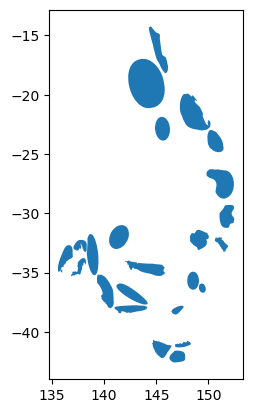

In [21]:
nem_grids[nem_grids["grid"] == "NEM_2030"].plot()

#### NWIS and SWIS

In [22]:
# Transmission lines
lines_gpd = geopandas.read_file(
    FILEPATH + "Electricity_Transmission_Lines/Electricity_Transmission_Lines.shp"
)

In [24]:
# Reproject to a metric CRS (metres)
# Use an appropriate UTM zone for your data
# Automatically estimate UTM from your geometries:
utm_crs = lines_gpd.estimate_utm_crs()
print(f"Using UTM projection: {utm_crs}")
lines_proj = lines_gpd.to_crs(utm_crs)

Using UTM projection: EPSG:32753


In [25]:
# Buffer 100 km = 100,000 metres
lines_proj["geometry"] = lines_proj.buffer(100_000)

In [26]:
# Reproject to EPSG:4326 (lat/lon)
lines_out = lines_proj.to_crs("EPSG:4326")

In [27]:
lines_out = lines_out.loc[lines_out["state"] == "Western Australia"]

In [30]:
import numpy as np

array(['Australian Capital Territory', 'New South Wales',
       'Northern Territory', 'Queensland', 'South Australia', 'Tasmania',
       'Victoria', 'Western Australia'], dtype=object)

In [23]:
# Merge
# lines_proj = lines_proj.dissolve()

<Axes: >

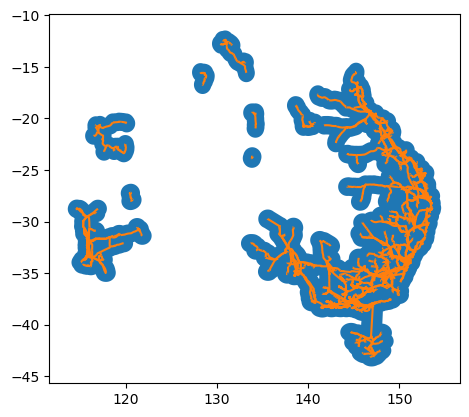

In [17]:
fig,ax=plt.subplots(1, 1)
lines_out.plot(ax=ax)
lines_gpd.plot(ax=ax, color="tab:orange")

In [28]:
def remove_region(gdf, xmin, ymin, xmax, ymax):
    """
    Return Geopandas DataFrame with polygons within bounds removed

    gdf: geopandas dataframe
    xmin, ymin, xmax, ymax: coords of box
    """
    bbox = box(xmin, ymin, xmax, ymax)
    return gdf[~gdf.intersects(bbox)]

In [29]:
# Remove microgrids
lines_filtered = remove_region(lines_out, 119, -29, 125, -25)
lines_filtered = remove_region(lines_filtered, 125, -17, 130, -10)

In [30]:
# Assign groups to NWIS and SWIS and dissolve by group
lat_split = -25
lines_filtered["rep_lat"] = lines_filtered.geometry.centroid.y
lines_filtered["region_group"] = (lines_filtered["rep_lat"] >= lat_split).astype(int)
lines_filtered_2 = lines_filtered.dissolve(by="region_group", as_index=False)

/jobfs/163720447.gadi-pbs/ipykernel_2035439/1524826010.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lines_filtered["rep_lat"] = lines_filtered.geometry.centroid.y


In [32]:
lines_filtered_2

,region_group,geometry,length_m,objectid,featuretyp,descriptio,class,name,operationa,state,spatialcon,revised,ga_guid,capacitykv,comment_,st_lengths,rep_lat
0,0,"POLYGON ((115.87166 -35.17654, 115.81915 -35.1...",89005.031866,1139,Transmission Line,A network of wires and insulators used to conn...,Overhead,Muja Terminal to Kojonup (North East),Operational,Western Australia,5,2012-07-10,{9172A221-F518-484B-B839-0E1ED4AFC34A},132,<Null>,0.925503,-33.629208
1,1,"POLYGON ((116.6985 -23.41454, 116.6918 -23.389...",98784.258943,1337,Transmission Line,A network of wires and insulators used to conn...,Overhead,South Hedland to Goldsworthy,Operational,Western Australia,5,2012-07-10,{A445BB40-F326-4B5F-B480-625C10332531},66,None,0.942640,-20.362905


<Axes: >

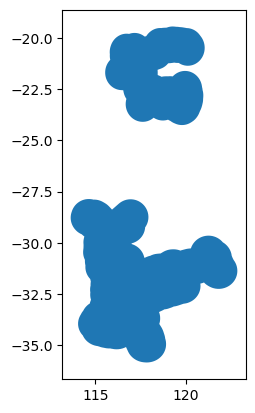

In [31]:
lines_filtered_2.plot()

In [65]:
lines_filtered_2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [88]:
nwis = geopandas.GeoDataFrame({'grid': ['NWIS'], 'geometry': lines_filtered_2.loc[1, "geometry"]}, crs="EPSG:4326")

In [89]:
swis = geopandas.GeoDataFrame({'grid': ['SWIS'], 'geometry': lines_filtered_2.loc[0, "geometry"]}, crs="EPSG:4326")

In [90]:
nem_grids = pd.concat([nem_grids, nwis], ignore_index=True)

In [91]:
nem_grids = pd.concat([nem_grids, swis], ignore_index=True)

In [92]:
nem_grids.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [93]:
nem_grids

,grid,geometry
0,NEM_2030,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3..."
1,SE_2030,"MULTIPOLYGON Z (((143.39392 -37.77456 0, 143.6..."
2,NWIS,"POLYGON ((116.6985 -23.41454, 116.6918 -23.389..."
3,SWIS,"POLYGON ((115.87166 -35.17654, 115.81915 -35.1..."


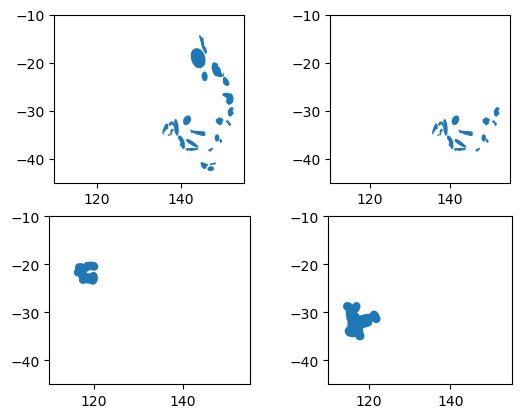

In [94]:
fig, ax = plt.subplots(2, 2)
for i in range(4):
    g = nem_grids.loc[i, "grid"]
    nem_grids[nem_grids["grid"] == g].plot(ax=ax.flatten()[i])
    ax.flatten()[i].set_xlim([110, 155])#, -10, -45])
    ax.flatten()[i].set_ylim([-45, -10])

In [95]:
type(nem_grids)

geopandas.geodataframe.GeoDataFrame

In [101]:
nem_grids.to_file(FILEPATH + "grids.shp", driver='ESRI Shapefile')

In [102]:
test = geopandas.read_file(
    FILEPATH + "grids.shp"
)

<Axes: >

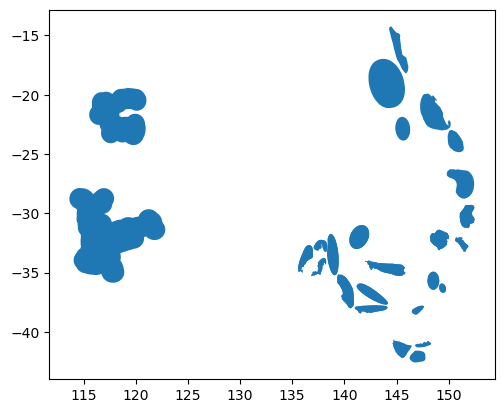

In [103]:
test.plot()

### Workflow to incorporate different capacities of each REZ

Abandon for now to focus on NEM and SE regions with equally weighted REZs. Preferable in one way because the decadal simulations are coarse, so we want to focus on the large scale wind, and using capacity weights will emphasise particular (small) regions (REZs). Weighting equally is closer to how the grid will evolve.

Put multiple grids in single dictionary

In [62]:
grid_region_map = {r: [] for r in rez_gpd.index}

for r in rez_gpd.index:
    for col, grid in zip(
        rez_gpd.columns[-4:],
        ["NEM_2025", "NEM_2030", "NEM_2040", "NEM_2050"]
    ):
        if rez_gpd.loc[r, col] > 0:
            grid_region_map[r].append(grid)
            
    if r in SE_grid_REZs:
        for col, grid in zip(
            rez_gpd.columns[-4:],
            ["SE_2025", "SE_2030", "SE_2040", "SE_2050"]
        ):
            if rez_gpd.loc[r, col] > 0:
                grid_region_map[r].append(grid)

In [64]:
grid_region_map["N2"]

['NEM_2025',
 'NEM_2030',
 'NEM_2040',
 'NEM_2050',
 'SE_2025',
 'SE_2030',
 'SE_2040',
 'SE_2050']

Expand the GeoDataFrame

In [117]:
rows = []

for _, row in rez_gpd.iterrows():
    small = row.name 
    
    for large in grid_region_map.get(small, []):
        new_row = row.copy()
        new_row["grid"] = large
        rows.append(new_row)

rez_gpd_expanded = geopandas.GeoDataFrame(rows, crs=rez_gpd.crs)

In [118]:
rez_gpd_expanded.head()

,Name,Type,longitude,latitude,geometry,Existing_wind,SC2030,SC2040,SC2050,grid
Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2025
Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2030
Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2040
Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2050
Q2,Q2 North Qld Clean Energy Hub,REZ,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",43,1993,2693.0,4743.0,NEM_2025


Compute weights for capacity

In [98]:
rows = []

for region in rez_gpd.index:
    for scen, grid in zip(
        rez_gpd.columns[-4:],
        ["NEM_2025", "NEM_2030", "NEM_2040", "NEM_2050"]
    ):
        rows.append({
            "REZ_id": region,
            "grid": grid,
            "capacity": rez_gpd.loc[region, scen]
        })

    if region in SE_grid_REZs:
        for scen, grid in zip(
            rez_gpd.columns[-4:],
            ["SE_2025", "SE_2030", "SE_2040", "SE_2050"]
        ):  
            rows.append({
                "REZ_id": region,
                "grid": grid,
                "capacity": rez_gpd.loc[region, scen]
            })

capacity_map = pd.DataFrame(rows)

In [101]:
capacity_map.iloc[50:60]

,REZ_id,grid,capacity
50,N2,SE_2040,7842.0
51,N2,SE_2050,7842.0
52,N3,NEM_2025,673.0
53,N3,NEM_2030,6123.0
54,N3,NEM_2040,6123.0
55,N3,NEM_2050,8473.0
56,N3,SE_2025,673.0
57,N3,SE_2030,6123.0
58,N3,SE_2040,6123.0
59,N3,SE_2050,8473.0


Capacity totals for each grid and scenario year

In [104]:
capacity_totals = capacity_map.groupby("grid")["capacity"].sum()
capacity_totals

grid
NEM_2025    12791.0
NEM_2030    37441.0
NEM_2040    61071.0
NEM_2050    75971.0
SE_2025      9626.0
SE_2030     24726.0
SE_2040     40206.0
SE_2050     49706.0
Name: capacity, dtype: float64

Weights for capacity

In [105]:
capacity_map["weight_capacity"] = (
    capacity_map["capacity"] /
    capacity_map["grid"].map(capacity_totals)
)

Equal weights

In [112]:
region_counts = capacity_map.groupby("grid")["REZ_id"].nunique()
region_counts

grid
NEM_2025    43
NEM_2030    43
NEM_2040    43
NEM_2050    43
SE_2025     30
SE_2030     30
SE_2040     30
SE_2050     30
Name: REZ_id, dtype: int64

In [113]:
capacity_map["weight_equal"] = 1 / capacity_map["grid"].map(region_counts)

In [114]:
capacity_map

,REZ_id,grid,capacity,weight_capacity,weight_equal
0,Q1,NEM_2025,332.0,0.025956,0.023256
1,Q1,NEM_2030,1082.0,0.028899,0.023256
2,Q1,NEM_2040,1132.0,0.018536,0.023256
3,Q1,NEM_2050,1432.0,0.018849,0.023256
4,Q2,NEM_2025,43.0,0.003362,0.023256
...,...,...,...,...,...
287,T3,NEM_2050,2444.0,0.032170,0.023256
288,T4,NEM_2025,0.0,0.000000,0.023256
289,T4,NEM_2030,0.0,0.000000,0.023256
290,T4,NEM_2040,0.0,0.000000,0.023256


Expand GeoDataFrame

In [154]:
rez_gpd_expanded = rez_gpd_expanded.reset_index().rename(columns={"index": "REZ_id"})

In [156]:
rez_gpd_expanded = rez_gpd_expanded.merge(
    capacity_map[["REZ_id", "grid", "weight_capacity", "weight_equal"]],
    on=["REZ_id", "grid"],
    how="left"
)

In [157]:
rez_gpd_expanded.head()

,REZ_id,Name,Type,longitude,latitude,geometry,Existing_wind,SC2030,SC2040,SC2050,grid,weight_capacity,weight_equal
0,Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2025,0.025956,0.023256
1,Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2030,0.028899,0.023256
2,Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2040,0.018536,0.023256
3,Q1,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",332,1082,1132.0,1432.0,NEM_2050,0.018849,0.023256
4,Q2,Q2 North Qld Clean Energy Hub,REZ,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",43,1993,2693.0,4743.0,NEM_2025,0.003362,0.023256


Dissolve by grid

In [158]:
nem_grids = rez_gpd_expanded.dissolve(
    by="grid", aggfunc={"Existing_wind": "sum", "SC2030": "sum", "SC2040": "sum", "SC2050": "sum"}, as_index=False)
#.drop(["Name", "Type", "longitude", "latitude"], axis=1)

In [159]:
nem_grids

,grid,geometry,Existing_wind,SC2030,SC2040,SC2050
0,NEM_2025,"MULTIPOLYGON Z (((143.62827 -37.77871 0, 143.7...",12791,33391,43791.0,57791.0
1,NEM_2030,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3...",12791,37441,50991.0,65891.0
2,NEM_2040,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3...",12791,37441,61071.0,75971.0
3,NEM_2050,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3...",12791,37441,61071.0,75971.0
4,SE_2025,"MULTIPOLYGON Z (((139.46212 -35.20118 0, 139.4...",9626,21676,27626.0,36226.0
5,SE_2030,"MULTIPOLYGON Z (((143.39392 -37.77456 0, 143.6...",9626,24726,31226.0,40726.0
6,SE_2040,"MULTIPOLYGON Z (((142.06683 -38.59774 0, 142.0...",9626,24726,40206.0,49706.0
7,SE_2050,"MULTIPOLYGON Z (((142.06683 -38.59774 0, 142.0...",9626,24726,40206.0,49706.0


<Axes: >

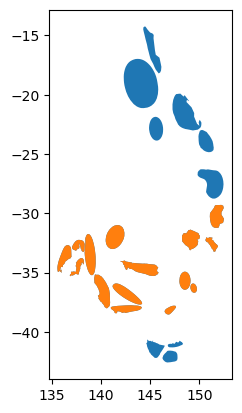

In [17]:
fig, ax = plt.subplots(1,1)

rez_gpd.loc[rez_gpd["SC2030"] > 0].plot(ax=ax)

rez_gpd.loc[
    (rez_gpd["SC2030"] > 0) &
    (rez_gpd["REZ_id"].isin(SE_grid_REZs))
    ].plot(ax=ax, color="tab:orange")

In [18]:
rez_gpd.head()

,Name,Type,longitude,latitude,geometry,REZ_id,Existing_wind,SC2030,SC2040,SC2050
0,Q1 Far North QLD,REZ,145.123721,-16.187650,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",Q1,332,1082,1132.0,1432.0
1,Q2 North Qld Clean Energy Hub,REZ,144.062266,-19.110858,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",Q2,43,1993,2693.0,4743.0
2,Q3 Northern Qld,REZ,146.333143,-19.197589,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1...",Q3,0,0,0.0,0.0
3,Q4 Isaac,REZ,148.339869,-21.393793,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -...",Q4,439,1439,2339.0,4239.0
4,Q5 Barcaldine,REZ,145.595326,-22.855731,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2...",Q5,0,100,100.0,100.0
